In [1]:
import pandas as pd
import json
import numpy as np
import os
import torch
from PIL import Image
from mmengine.config import Config
from transformers import set_seed
import random
import cv2
import h5py
import logging
from logging import Logger
from tqdm import tqdm
from datetime import datetime
from sklearn.metrics import precision_recall_curve, roc_auc_score, accuracy_score

/home/firdavs/miniconda3/envs/firdavs/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LOGGING_PATH = f'/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/logging/evaluate_vis_embs-dt=({datetime.now().strftime("%Y-%m-%d-%H-%M")}).log'
EMBEDDINGS_DIR = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/embeddings/vision/'
OUTPUT_DIR = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/evals/cluster_iat/'

# ALL_ANNOTATIONS_PATH = '/home/firdavs/surgery/surgical_fb_generxation/SurgicalFeedbackGeneration/data/urology-related/annotations/cmb_all_mapped.csv'
# ALL_ANNOTATIONS_PATH = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/data/urology-related/annotations/cmb_all-rafal_cluster_mappings.csv'
ALL_ANNOTATIONS_PATH = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/data/urology-related/annotations/cmb_all-o3_cluster_mappings.csv'

def set_seed_all(seed, logger: Logger = None):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    set_seed(seed)
    print(f"Set seed: {seed}")
    if logger:
        logger.info(f"Set seed: {seed}")

set_seed_all(SEED)

Set seed: 42


In [3]:
def load_tmp_df():
    dir_ = '/home/firdavs/surgery/rafal_experiments/fbk_cuts_with_instruments'
    tmp_dfs = []
    for file in os.listdir(dir_):
        path = os.path.join(dir_, file)
        if not path.endswith('.csv'): continue
        tmp_df = pd.read_csv(path)
        tmp_dfs.append(tmp_df)
    tmp_df = pd.concat(tmp_dfs)
    tmp_df = tmp_df.drop(columns=['Unnamed: 0'])
    tmp_df.sort_values(by=['Case', 'Timestamp'], inplace=True)
    tmp_df.reset_index(drop=True, inplace=True)
    return tmp_df
tmp_df = load_tmp_df()

In [4]:
def load_annotations_df(iat_cols = ['instrument-cluster', 'action-cluster', 'tissue-cluster']):
    annotations_df = pd.read_csv(ALL_ANNOTATIONS_PATH)
    fbk_cols = [col for col in annotations_df.columns if col.startswith('f_')]
    annotations_df = annotations_df[['Dialogue', 'Timestamp', 'Case'] + iat_cols + fbk_cols]
    annotations_df['Timestamp'] = annotations_df['Timestamp'].apply(lambda x: f"{int(x.split(':')[0]):02d}:{int(x.split(':')[1]):02d}:{int(x.split(':')[2]):02d}")
    annotations_df.sort_values(by=['Case', 'Timestamp'], inplace=True)
    annotations_df.reset_index(drop=True, inplace=True)
    return annotations_df

all_annotations_df = load_annotations_df()
all_annotations_df['cvid'] = tmp_df['cvid']

In [5]:
all_annotations_df[all_annotations_df['cvid'] == 'c1_s0_2-20-5.avi']

,Dialogue,Timestamp,Case,instrument-cluster,action-cluster,tissue-cluster,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid
327,"more retraction, please... on the prostate sid...",10:57:30,1,retractor,apply_traction,prostate_tissue,0,0,1,0,1,0,0.0,c1_s0_2-20-5.avi


In [6]:
def load_procedures_df():
    procedures_df = pd.read_parquet('../data/urology-related/procedures.parquet')
    return procedures_df

def load_teaching_steps_df():
    teaching_steps_df = pd.read_parquet('../data/urology-related/teaching_steps.parquet')
    teaching_steps_df = teaching_steps_df.sort_values(by=['case_id', 'end_secs'])
    teaching_steps_df.reset_index(drop=True, inplace=True)
    for i in range(len(teaching_steps_df)):
        if i == 0:
            continue
        if teaching_steps_df.loc[i, 'case_id'] == teaching_steps_df.loc[i-1, 'case_id']:
            teaching_steps_df.loc[i, 'start_secs'] = teaching_steps_df.loc[i-1, 'end_secs']
    return teaching_steps_df

procedures_df = load_procedures_df()
teaching_steps_df = load_teaching_steps_df()

In [7]:
teaching_steps_df['duration'] = teaching_steps_df['end_secs'] - teaching_steps_df['start_secs']
teaching_steps_df['duration'].mean()

np.float64(546.4744376278119)

In [8]:
teaching_step_case_count = []
for case_id in teaching_steps_df['case_id'].unique():
    case_df = teaching_steps_df[teaching_steps_df['case_id'] == case_id]
    teaching_step_case_count.append(len(case_df))
np.mean(teaching_step_case_count)

np.float64(15.28125)

In [9]:
def add_vis_embs(name, annotations_df, force=False):
    annotations_df = annotations_df.copy()
    col_name = f'{name}_vis_embs'
    if col_name not in annotations_df.columns or force:
        embs_path = os.path.join(EMBEDDINGS_DIR, f"{name}_fbk_vis_embs.h5")
        embs_h5 = h5py.File(embs_path, 'r')
        annotations_df[col_name] = annotations_df['cvid'].apply(lambda x: embs_h5[x][:] if x in embs_h5 else None)
        embs_h5.close()
    return annotations_df

# all_annotations_df = add_vis_embs('surgvlp', all_annotations_df)
# all_annotations_df = add_vis_embs('hecvl', all_annotations_df)
all_annotations_df = add_vis_embs('peskavlp', all_annotations_df)
# all_annotations_df = add_vis_embs('videomae_urology', all_annotations_df)
# all_annotations_df = add_vis_embs('videomae_cholect45', all_annotations_df)
# all_annotations_df = add_vis_embs('pe224', all_annotations_df)
# all_annotations_df = add_vis_embs('pe336', all_annotations_df)
# all_annotations_df = add_vis_embs('pe448', all_annotations_df)

In [10]:
vis_emb_cols = [col for col in all_annotations_df.columns if col.endswith('_vis_embs')]
for col in vis_emb_cols:
    print(f"{col}: {all_annotations_df.iloc[0][col].shape if isinstance(all_annotations_df.iloc[0][col], np.ndarray) else 'None'}")

peskavlp_vis_embs: (50, 768)


In [11]:
import json
print(json.dumps({
    'instrument-cluster': all_annotations_df['instrument-cluster'].replace(np.nan, 'NONE').value_counts().to_dict(),
    'action-cluster': all_annotations_df['action-cluster'].replace(np.nan, 'NONE').value_counts().to_dict(),
    'tissue-cluster': all_annotations_df['tissue-cluster'].replace(np.nan, 'NONE').value_counts().to_dict(),
}, indent=2))

{
  "instrument-cluster": {
    "NONE": 3646,
    "left_hand": 98,
    "energy_device": 81,
    "fourth_arm": 71,
    "stitch": 43,
    "needle": 40,
    "suture_material": 29,
    "clip": 27,
    "scissors": 27,
    "retractor": 26,
    "right_hand": 19,
    "graspers": 18,
    "catheter": 17,
    "camera": 16,
    "suction": 11,
    "general_instrument": 10,
    "bipolar": 10,
    "stapler": 9,
    "needle_driver": 6,
    "spreader": 4,
    "balloon": 1,
    "arm_instrument": 1
  },
  "action-cluster": {
    "NONE": 3197,
    "grasp": 146,
    "coagulate": 87,
    "open": 81,
    "perform_sweeping_maneuvers": 69,
    "navigate_space": 57,
    "ensure_safety": 57,
    "apply_traction": 54,
    "control_depth": 52,
    "stop": 50,
    "adjust_direction": 44,
    "turn": 42,
    "inspect": 39,
    "cut": 36,
    "release_instrument": 33,
    "continue_action": 31,
    "spread": 25,
    "adjust": 25,
    "dissect": 24,
    "suture": 14,
    "rotate": 9,
    "maintain_position": 7,
    "p

## Remap o3 clusters

In [12]:
instrument_remapping_path = '../data/urology-related/o3_instrument_clusters-remapped.json'
action_remapping_path = '../data/urology-related/o3_action_clusters-remapped.json'
tissue_remapping_path = '../data/urology-related/o3_tissue_clusters-remapped.json'

with open(instrument_remapping_path, 'r') as f:
    instrument_remapping = json.load(f)
with open(action_remapping_path, 'r') as f:
    action_remapping = json.load(f)
with open(tissue_remapping_path, 'r') as f:
    tissue_remapping = json.load(f)
    
all_annotations_df['instrument-cluster_remapped'] = all_annotations_df['instrument-cluster'].replace(instrument_remapping)
all_annotations_df['action-cluster_remapped'] = all_annotations_df['action-cluster'].replace(action_remapping)
all_annotations_df['tissue-cluster_remapped'] = all_annotations_df['tissue-cluster'].replace(tissue_remapping)

In [13]:
import json
print(json.dumps({
    'instrument-cluster_remapped': all_annotations_df['instrument-cluster_remapped'].replace(np.nan, 'NONE').value_counts().to_dict(),
    'action-cluster_remapped': all_annotations_df['action-cluster_remapped'].replace(np.nan, 'NONE').value_counts().to_dict(),
    'tissue-cluster_remapped': all_annotations_df['tissue-cluster_remapped'].replace(np.nan, 'NONE').value_counts().to_dict(),
}, indent=2))

{
  "instrument-cluster_remapped": {
    "NONE": 3646,
    "hand_control": 118,
    "suturing_tools": 118,
    "energy_device": 91,
    "auxiliary_arm": 71,
    "retractor_device": 30,
    "surgical_scissors": 27,
    "clip_device": 27,
    "grasping_tools": 18,
    "catheter": 17,
    "camera": 16,
    "suction_device": 11,
    "general_instrument": 10,
    "stapler": 9,
    "balloon": 1
  },
  "action-cluster_remapped": {
    "NONE": 3197,
    "navigate_position": 160,
    "grip_hold": 151,
    "open_spread": 106,
    "coagulate": 87,
    "sweeping_maneuvers": 69,
    "interrupt_action": 57,
    "ensure_safety": 57,
    "traction_retract": 56,
    "rotate_turn": 51,
    "cut_divide": 40,
    "inspect": 39,
    "release_instrument": 33,
    "continue_action": 31,
    "adjust_fix": 26,
    "dissect_clean": 25,
    "suture_tie": 16,
    "lift_elevate": 5,
    "expose": 2,
    "occlude": 2
  },
  "tissue-cluster_remapped": {
    "NONE": 3511,
    "urinary_tract": 162,
    "vascular_neuro

In [14]:
# i_col = 'instrument-cluster_remapped'
# a_col = 'action-cluster_remapped'
# t_col = 'tissue-cluster_remapped'
# iat_cols = [i_col, a_col, t_col]

# sample_df_IVT = all_annotations_df.dropna(subset=iat_cols).sample(n=3, random_state=0)
# sample_df_I = all_annotations_df.dropna(subset=[i_col]).sample(n=1, random_state=0)
# sample_df_A = all_annotations_df.dropna(subset=[a_col]).sample(n=1, random_state=0)
# sample_df_T = all_annotations_df.dropna(subset=[t_col]).sample(n=1, random_state=0)
# sample_indices = list(sample_df_IVT.index) + list(sample_df_I.index) + list(sample_df_A.index) + list(sample_df_T.index)
# annotations_df = all_annotations_df[~all_annotations_df.index.isin(sample_indices)]
# sample_df = all_annotations_df[all_annotations_df.index.isin(sample_indices)]

# len(sample_df)

annotations_df = all_annotations_df.copy()

## Evaluate

In [15]:
LABEL_FILTER = 20
INCLUDE_NONE_LABEL = 100
NUM_FOLDS = 5

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, average_precision_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
import numpy as np
from imblearn.over_sampling import SMOTE

def evaluate(processed_df, metric_avg='weighted', sampler=None, num_folds=NUM_FOLDS, hidden_layer_sizes=(128, 64)):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    auprc_scores = []
    auroc_scores = []
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    confusion_matrices = []

    # pred_rows = []

    # Unique labels
    embeddings = np.array(processed_df['embedding'].values.tolist())
    labels  = np.array(processed_df['label'].values.tolist())
    pred_df = processed_df.copy()
    unique_labels = list(set(labels))
    fold_num = 1
    for train_index, test_index in skf.split(embeddings, labels):
        print(f"Fold {fold_num}/{num_folds}")
        fold_num += 1
        X_train, X_test = embeddings[train_index], embeddings[test_index]
        y_train, y_test = labels[train_index], labels[test_index]
        
        if sampler is not None:
            X_train, y_train = sampler.fit_resample(X_train, y_train)
        
        # Initialize and train a 2-layer MLP with ReLU activation
        model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='relu', max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        
        # Predict the test set
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)
        
        # for i, idx in enumerate(test_index):
        #     pred_rows.append({
        #         'test_index':  idx,
        #         'pred': y_pred[i],
        #         'pred_prob': y_pred_prob[i],
        #         'true': y_test[i],
        #     })
        pred_df.loc[test_index, 'pred'] = y_pred
        
        # Evaluate metrics
        auprc_scores.append(average_precision_score(y_test, y_pred_prob, average=metric_avg))
        auroc_scores.append(roc_auc_score(y_test, y_pred_prob, multi_class='ovo', average=metric_avg if metric_avg is not None else 'weighted'))
        accuracy_scores.append(accuracy_score(y_test, y_pred, normalize=True))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0, average=metric_avg))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0, average=metric_avg))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0, average=metric_avg))
        confusion_matrices.append(confusion_matrix(y_test, y_pred, labels=unique_labels))
    
    mean_auprc = np.mean(auprc_scores)
    mean_auroc = np.mean(auroc_scores)
    mean_accuracy = np.mean(accuracy_scores)
    mean_precision = np.mean(precision_scores)
    mean_recall = np.mean(recall_scores)
    mean_f1 = np.mean(f1_scores)
    
    # pred_df = pd.DataFrame(pred_rows)
    # pred_df['correct'] = pred_df['pred'] == pred_df['true']
    # pred_df = pred_df.sort_values(by=['test_index'])

    return {
        'auprc_scores': auprc_scores,
        'auroc_scores': auroc_scores,
        'accuracy_scores': accuracy_scores,
        'precision_scores': precision_scores,
        'recall_scores': recall_scores,
        'f1_scores': f1_scores,
        'auprc_mean': mean_auprc,
        'auroc_mean': mean_auroc,
        'accuracy_mean': mean_accuracy,
        'precision_mean': mean_precision,
        'recall_mean': mean_recall,
        'f1_mean': mean_f1,
        'confusion_matrix': np.sum(confusion_matrices, axis=0),
        'confusion_matrix_labels': unique_labels,
    }, pred_df

### 1) Vision

In [17]:
def get_vision_embeddings_and_labels(annotations_df, col, model, label_filter:int = LABEL_FILTER, include_none_label=INCLUDE_NONE_LABEL):
    df = annotations_df.dropna(subset=[f'{model}_vis_embs']).copy()
    if include_none_label == 'all':
        df[col] = df[col].replace(np.nan, 'None')
    elif isinstance(include_none_label, int) and include_none_label > 0:
        # all df[col] that are np.nan sample include_none_label amount
        df_none = df[df[col].isna()]
        df_none = df_none.sample(n=include_none_label, random_state=SEED)
        df_none[col] = 'None'
        df = pd.concat([df, df_none])
        
    if label_filter is not None:    # Remove labels with less than label_filter counts
        df = df[df[col].map(df[col].value_counts()) >= label_filter]
    embeddings_avg = np.array(df[f'{model}_vis_embs'].values.tolist()).mean(axis=1)
    labels = np.array(df[col].values.tolist())
    df['embedding'] = list(embeddings_avg)
    df['label'] = list(labels)
    df = df.reset_index(drop=True)
    return df

task = 'instrument'
col = 'instrument-cluster_remapped'
model = 'peskavlp'
processed_df = get_vision_embeddings_and_labels(annotations_df, col, model, label_filter=LABEL_FILTER, include_none_label=INCLUDE_NONE_LABEL)
metrics, pred_df = evaluate(processed_df, metric_avg='weighted', num_folds=5)

print(f"Mean AUPRC: {metrics['auprc_mean']:.4f}")
print(f"Mean AUROC: {metrics['auroc_mean']:.4f}")
print(f"Mean Accuracy: {metrics['accuracy_mean']:.4f}")
print(f"Mean Precision: {metrics['precision_mean']:.4f}")
print(f"Mean Recall: {metrics['recall_mean']:.4f}")
print(f"Mean F1: {metrics['f1_mean']:.4f}")

Fold 1/5


Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Mean AUPRC: 0.3266
Mean AUROC: 0.6599
Mean Accuracy: 0.3144
Mean Precision: 0.3175
Mean Recall: 0.3144
Mean F1: 0.3113


In [18]:
len(pred_df), len(pred_df[pred_df['label'] == pred_df['pred']])

(582, 183)

PeskaVLP instrument:
Mean AUPRC: 0.3121
Mean AUROC: 0.6950
Mean Accuracy: 0.2812
Mean Precision: 0.2893
Mean Recall: 0.2812
Mean F1: 0.2765


PeskaVLP instrument remapped:
Mean AUPRC: 0.3441
Mean AUROC: 0.6740
Mean Accuracy: 0.3518
Mean Precision: 0.3678
Mean Recall: 0.3518
Mean F1: 0.3501

In [19]:
vision_results_rows = []
models = ['pe224'] + ['surgvlp', 'hecvl', 'peskavlp'] + ['videomae-urology', 'videomae-cholect45']
for model in models:
    for task in ['instrument', 'action', 'tissue']:
        col = f'{task}-cluster'
        print(f"Model: {model}, Task: {task}")
        processed_df, embeddings_avg, labels = get_vision_embeddings_and_labels(annotations_df, col, model)
        metrics, final_model = evaluate(embeddings_avg, labels, metric_avg='weighted')
        # sample_predictions = get_sample_predictions(final_model, sample_df, col, model, 'vision')
        vision_results_rows.append({
            'model': model,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
            # 'sample_predictions': sample_predictions
        })
vision_results_df = pd.DataFrame(vision_results_rows)

Model: pe224, Task: instrument


KeyError: ['pe224_vis_embs']

In [ ]:
vision_results_path = os.path.join(OUTPUT_DIR, f'vision_results-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)
vision_results_df.to_csv(vision_results_path, index=False)
# vision_results_df = pd.read_csv(vision_results_path)
vision_results_df

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,pe224,instrument,0.300017,0.695255,0.307286,0.302672,0.307286,0.298561,"[[4, 2, 1, 5, 3, 2, 6, 1, 1, 2], [1, 6, 1, 3, ...","[clip, scissors, stitch, None, left_hand, four..."
1,pe224,action,0.174986,0.620547,0.175534,0.176859,0.175534,0.169419,"[[5, 2, 4, 0, 4, 2, 1, 1, 1, 2, 5, 5, 7, 4, 0,...","[navigate_space, adjust_direction, None, sprea..."
2,pe224,tissue,0.349012,0.721271,0.325877,0.307356,0.325877,0.301084,"[[7, 0, 7, 2, 0, 1, 11, 0, 10, 0, 2], [0, 3, 1...","[gi_tract, adrenal_kidney_region, vascular_and..."


In [ ]:
def convert_np_arr_str_to_arr(arr_str: str) -> np.ndarray:
    import re
    # grab everything that sits between a pair of brackets: [...numbers...]
    row_chunks = re.findall(r'\[([^\[\]]+)\]', arr_str)
    rows = [list(map(int, chunk.split())) for chunk in row_chunks]
    return np.array(rows)

def plot_confusion_matrices(confusion_matrices_df, suptitle, models: list = str):
    import matplotlib.pyplot as plt
    import numpy as np

    tasks_order  = ['instrument', 'action', 'tissue']

    # df_plot = vision_confusion_matrices_df.set_index(['model', 'task'])
    df_plot = confusion_matrices_df.set_index(['model', 'task'])
    

    # --- 3 rows (tasks) × 5 columns (models) -----------------
    n_rows, n_cols = len(tasks_order), len(models)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
    # fig.suptitle("Vision-only Confusion Matrices", fontsize=14)
    fig.suptitle(suptitle, fontsize=14)

    for i, task in enumerate(tasks_order):               # rows = tasks (top → bottom)
        for j, model in enumerate(models):               # cols = models (left → right)
            ax = axes[i, j]
            row = df_plot.loc[(model, task)]
            try:
                cm  = convert_np_arr_str_to_arr(row['confusion_matrix'])
            except Exception as e:
                continue
            labels = row['confusion_matrix_labels']

            ax.imshow(cm, origin='upper')                # default colormap
            # ax.set_xticks(range(len(labels)), labels, rotation=45, ha='right')
            # ax.set_yticks(range(len(labels)), labels if j == 0 else [])  # y‑labels only on 1st col
            ax.set_title(model, fontsize=9) if i == 0 else None          # titles only on top row
            if j == 0:
                ax.set_ylabel(f'{task}\nTrue')
            ax.set_xlabel('Predicted')

            for (x, y), v in np.ndenumerate(cm):
                ax.text(y, x, int(v), ha='center', va='center', fontsize=7)

    fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave room for suptitle
    plt.show()

# plot_confusion_matrices(vision_results_df, 'Vision-only Confusion Matrices')

### 2) Vision-Language

In [20]:
def get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name, label_filter:int = LABEL_FILTER, include_none_label=INCLUDE_NONE_LABEL):
    df = annotations_df.dropna(subset=[f'{model_name}_vis_embs']).copy()
    
    if include_none_label == 'all':
        df[col] = df[col].replace(np.nan, 'None')
    elif isinstance(include_none_label, int) and include_none_label > 0:
        # all df[col] that are np.nan sample include_none_label amount
        df_none = df[df[col].isna()]
        df_none = df_none.sample(n=include_none_label, random_state=SEED)
        df_none[col] = 'None'
        df = pd.concat([df, df_none])
        
    if label_filter is not None:    # Remove labels with less than label_filter counts
        df = df[df[col].map(df[col].value_counts()) >= label_filter]
    
    # Vision embeddings
    vis_embs_avg = np.array(df[f'{model_name}_vis_embs'].values.tolist()).mean(axis=1)
    
    emb_col = ''
    if model_name == 'surgvlp': emb_col = 'SurgVLP'
    elif model_name == 'hecvl': emb_col = 'HecVL'
    elif model_name == 'peskavlp': emb_col = 'PeskaVLP'
    elif model_name == 'pe224' or model_name == 'pe336' or model_name == 'pe448': emb_col = 'MedEmbed_small'
    elif model_name == 'videomae_urology' or model_name == 'videomae_cholect45': emb_col = 'MedEmbed_small'
    else:
        raise ValueError(f"Model name {model_name} is not supported.")
    print(f"Embedding column: {emb_col}")
    
    # Procedure embeddings
    procedure_embs = []
    for i in range(len(df)):
        case = df.iloc[i]['Case']
        tmp_df = procedures_df[procedures_df['case_id'] == case]
        procedure_embs.append(tmp_df[f"procedure_defn_emb-{emb_col}"].values[0])
    procedure_embs = np.array(procedure_embs)
    
    # Teaching step embeddings
    teaching_step_embs = []
    df['secs'] = df['cvid'].apply(lambda x: sum([a*b for a,b in zip(map(int, x.split('_')[-1][:-4].split('-')), [3600, 60, 1])]))
    for i in range(len(df)):
        secs = df.iloc[i]['secs']
        case = df.iloc[i]['Case']
        tmp_df = teaching_steps_df[teaching_steps_df['case_id'] == case]
        tmp_df = tmp_df[(tmp_df['start_secs'] <= secs) & (tmp_df['end_secs'] > secs)]
        emb_size = len(teaching_steps_df[f"teaching_step_defn_emb-{emb_col}"].iloc[0])
        if len(tmp_df) == 0:
            # print(f"No teaching step found for case {case} and timestamp {secs}")
            teaching_step_embs.append(np.zeros(emb_size))
        elif len(tmp_df) > 1:
            print(f"Multiple teaching steps found for case {case} and timestamp {secs}")
            teaching_step_embs.append(np.zeros(emb_size))
        else:
            teaching_step_embs.append(tmp_df[f"teaching_step_defn_emb-{emb_col}"].values[0])
    teaching_step_embs = np.array(teaching_step_embs)
    
    # Labels
    labels = np.array(df[col].values.tolist())
    
    df['vis_embs_avg'] = list(vis_embs_avg)
    df['procedure_embs'] = list(procedure_embs)
    df['teaching_step_embs'] = list(teaching_step_embs)
    df['label'] = list(labels)
    df = df.reset_index(drop=True)
    
    return df

task = 'instrument'
col = 'instrument-cluster_remapped'
model_name = 'peskavlp'
processed_df = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name)
vis_embs_avg = np.array(processed_df['vis_embs_avg'].values.tolist())
procedure_embs = np.array(processed_df['procedure_embs'].values.tolist())
teaching_step_embs = np.array(processed_df['teaching_step_embs'].values.tolist())
embeddings_comb = np.concatenate([vis_embs_avg, procedure_embs, teaching_step_embs], axis=1)
processed_df['embedding'] = list(embeddings_comb)

metrics, pred_df = evaluate(processed_df, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))

print(f"Mean AUPRC: {metrics['auprc_mean']:.4f}")
print(f"Mean AUROC: {metrics['auroc_mean']:.4f}")
print(f"Mean Accuracy: {metrics['accuracy_mean']:.4f}")
print(f"Mean Precision: {metrics['precision_mean']:.4f}")
print(f"Mean Recall: {metrics['recall_mean']:.4f}")
print(f"Mean F1: {metrics['f1_mean']:.4f}")

Embedding column: PeskaVLP
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Mean AUPRC: 0.3534
Mean AUROC: 0.7021
Mean Accuracy: 0.3368
Mean Precision: 0.3382
Mean Recall: 0.3368
Mean F1: 0.3323


In [ ]:
break

In [ ]:
Mean AUPRC: 0.3555
Mean AUROC: 0.6963
Mean Accuracy: 0.3384
Mean Precision: 0.3314
Mean Recall: 0.3384
Mean F1: 0.3304

In [ ]:
vl_both_results_rows = []
# models = ['pe224'] + ['surgvlp', 'hecvl', 'peskavlp'] + ['videomae_urology', 'videomae_cholect45']
# models = ['videomae_urology', 'videomae_cholect45']
# models = ['pe336']
models = ['peskavlp']
pred_dfs_both = {}
for model_name in models:
    for task in ['instrument', 'action', 'tissue']:
        col = f'{task}-cluster_remapped'
        print(f"Model: {model_name}, Task: {task}")
        processed_df = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name)
        vis_embs_avg = np.array(processed_df['vis_embs_avg'].values.tolist())
        procedure_embs = np.array(processed_df['procedure_embs'].values.tolist())
        teaching_step_embs = np.array(processed_df['teaching_step_embs'].values.tolist())
        embeddings_comb = np.concatenate([vis_embs_avg, procedure_embs, teaching_step_embs], axis=1)
        processed_df['embedding'] = list(embeddings_comb)
        metrics, pred_df = evaluate(processed_df, metric_avg='weighted', hidden_layer_sizes=(256, 64))
        # sample_predictions = get_sample_predictions(final_model, sample_df, col, model_name, 'vision+proc+step')
        vl_both_results_rows.append({
            'model': model_name,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
            # 'sample_predictions': sample_predictions
        })
        pred_dfs_both[f"{model_name}--{col}"] = pred_df
vl_both_results_df = pd.DataFrame(vl_both_results_rows)

Model: peskavlp, Task: instrument
Embedding column: PeskaVLP
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5


Fold 5/5
Model: peskavlp, Task: action
Embedding column: PeskaVLP
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Model: peskavlp, Task: tissue
Embedding column: PeskaVLP
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


In [ ]:
pred_dfs_both.keys()

dict_keys(['peskavlp--instrument-cluster_remapped', 'peskavlp--action-cluster_remapped', 'peskavlp--tissue-cluster_remapped'])

In [ ]:
import pickle
with open(os.path.join(
    OUTPUT_DIR,
    f'vL_both_pred_dfs-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.pkl'
), 'wb') as f:
    pickle.dump(pred_dfs_both, f)

In [ ]:
vl_both_results_path = os.path.join(OUTPUT_DIR, f'vl_both_results-o3_clusters-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)
# vl_both_results_df.to_csv(vl_both_results_path, index=False)
# vl_both_results_df

vl_both_results_df_old = pd.read_csv(vl_both_results_path)
vl_both_results_df_old

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,pe224,instrument,0.313236,0.710977,0.303617,0.303513,0.303617,0.295547,[[ 1 1 0 9 5 1 7 0 1 2]\n [ 3 3 1 ...,"[np.str_('clip'), np.str_('scissors'), np.str_..."
1,pe224,action,0.176498,0.629705,0.173620,0.171561,0.173620,0.165921,[[ 2 3 7 0 4 0 3 3 0 2 5 2 7 2 1...,"[np.str_('navigate_space'), np.str_('adjust_di..."
2,pe224,tissue,0.377219,0.745880,0.365316,0.342297,0.365316,0.329104,[[13 0 6 4 1 0 6 0 7 1 2]\n [ 0 3 ...,"[np.str_('gi_tract'), np.str_('adrenal_kidney_..."
3,surgvlp,instrument,0.284394,0.687881,0.264451,0.268454,0.264451,0.259260,[[ 4 2 1 6 4 2 6 0 0 2]\n [ 2 5 0 ...,"[np.str_('clip'), np.str_('scissors'), np.str_..."
4,surgvlp,action,0.172917,0.624281,0.186999,0.174063,0.186999,0.175838,[[ 2 2 4 2 4 1 4 3 1 2 7 1 5 1 1...,"[np.str_('navigate_space'), np.str_('adjust_di..."
5,surgvlp,tissue,0.343825,0.728577,0.339018,0.338560,0.339018,0.329639,[[11 0 2 1 2 1 9 0 8 0 6]\n [ 0 3 ...,"[np.str_('gi_tract'), np.str_('adrenal_kidney_..."
6,hecvl,instrument,0.303955,0.712397,0.264417,0.260748,0.264417,0.256630,[[ 3 1 1 6 5 3 5 0 1 2]\n [ 1 8 0 ...,"[np.str_('clip'), np.str_('scissors'), np.str_..."
7,hecvl,action,0.173200,0.617692,0.168863,0.168139,0.168863,0.161595,[[ 2 5 3 1 3 1 5 1 2 1 4 2 6 2 2...,"[np.str_('navigate_space'), np.str_('adjust_di..."
8,hecvl,tissue,0.359333,0.735307,0.370597,0.360436,0.370597,0.351804,[[ 9 0 3 3 1 2 14 0 4 2 2]\n [ 0 3 ...,"[np.str_('gi_tract'), np.str_('adrenal_kidney_..."
9,peskavlp,instrument,0.314853,0.709074,0.305348,0.320505,0.305348,0.301221,[[ 1 0 2 7 9 1 3 0 2 2]\n [ 3 4 0 ...,"[np.str_('clip'), np.str_('scissors'), np.str_..."


In [ ]:
vl_both_results_path_remapped = os.path.join(OUTPUT_DIR, f'vl_both_results-o3_clusters_remapped-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.csv')
pd.read_csv(vl_both_results_path_remapped)

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,pe224,instrument,0.353334,0.700128,0.334528,0.341777,0.334528,0.329460,[[44 2 23 6 6 17 13 7]\n [ 6 5 0 4 3 ...,"['hand_control', 'surgical_scissors', 'suturin..."
1,pe224,action,0.185111,0.626765,0.184511,0.181979,0.184511,0.178575,[[18 2 4 1 1 11 8 4 2 0 1 3 1 1 1...,"['sweeping_maneuvers', 'ensure_safety', 'open_..."
2,pe224,tissue,0.372413,0.738624,0.365145,0.361718,0.365145,0.350798,[[ 9 5 1 2 5 7 4 0 3 5]\n [ 3 13 1 ...,"['fat_fascial_peritoneal_planes', 'gastrointes..."
3,surgvlp,instrument,0.347621,0.688300,0.358726,0.357964,0.358726,0.349423,[[40 3 26 12 6 15 11 5]\n [10 4 1 4 1 ...,"['hand_control', 'surgical_scissors', 'suturin..."
4,surgvlp,action,0.181821,0.620472,0.177129,0.175791,0.177129,0.172472,[[15 4 6 0 2 6 15 4 3 3 2 1 1 0 1...,"['sweeping_maneuvers', 'ensure_safety', 'open_..."
5,surgvlp,tissue,0.362420,0.733725,0.357419,0.362732,0.357419,0.351085,[[ 8 4 1 5 6 9 2 1 2 3]\n [ 2 9 1 ...,"['fat_fascial_peritoneal_planes', 'gastrointes..."
6,hecvl,instrument,0.348677,0.699920,0.346732,0.343362,0.346732,0.335412,[[46 1 23 7 3 20 9 9]\n [ 5 5 0 4 2 ...,"['hand_control', 'surgical_scissors', 'suturin..."
7,hecvl,action,0.175139,0.613787,0.188193,0.187020,0.188193,0.183330,[[18 2 9 2 1 8 10 2 0 4 0 2 0 1 0...,"['sweeping_maneuvers', 'ensure_safety', 'open_..."
8,hecvl,tissue,0.372299,0.745558,0.384450,0.383237,0.384450,0.376779,[[10 4 2 1 4 7 4 0 3 6]\n [ 4 9 0 ...,"['fat_fascial_peritoneal_planes', 'gastrointes..."
9,peskavlp,instrument,0.361325,0.700242,0.346672,0.349330,0.346672,0.341131,[[37 4 20 11 4 21 12 9]\n [ 5 4 0 4 2 ...,"['hand_control', 'surgical_scissors', 'suturin..."


In [ ]:
vl_both_results_df_new = pd.concat([vl_both_results_df_old, vl_both_results_df])
vl_both_results_df_new['confusion_matrix_labels'] = vl_both_results_df_new['confusion_matrix_labels'].apply(lambda x: [str(y) for y in eval(x)] if isinstance(x, str) else x)
# vl_both_results_df_new = vl_both_results_df_new.sort_values(by=['model', 'task'])
vl_both_results_df_new.to_csv(vl_both_results_path, index=False)
vl_both_results_df_new

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,pe224,instrument,0.353334,0.700128,0.334528,0.341777,0.334528,0.329460,[[44 2 23 6 6 17 13 7]\n [ 6 5 0 4 3 ...,"[hand_control, surgical_scissors, suturing_too..."
1,pe224,action,0.185111,0.626765,0.184511,0.181979,0.184511,0.178575,[[18 2 4 1 1 11 8 4 2 0 1 3 1 1 1...,"[sweeping_maneuvers, ensure_safety, open_sprea..."
2,pe224,tissue,0.372413,0.738624,0.365145,0.361718,0.365145,0.350798,[[ 9 5 1 2 5 7 4 0 3 5]\n [ 3 13 1 ...,"[fat_fascial_peritoneal_planes, gastrointestin..."
3,surgvlp,instrument,0.347621,0.688300,0.358726,0.357964,0.358726,0.349423,[[40 3 26 12 6 15 11 5]\n [10 4 1 4 1 ...,"[hand_control, surgical_scissors, suturing_too..."
4,surgvlp,action,0.181821,0.620472,0.177129,0.175791,0.177129,0.172472,[[15 4 6 0 2 6 15 4 3 3 2 1 1 0 1...,"[sweeping_maneuvers, ensure_safety, open_sprea..."
5,surgvlp,tissue,0.362420,0.733725,0.357419,0.362732,0.357419,0.351085,[[ 8 4 1 5 6 9 2 1 2 3]\n [ 2 9 1 ...,"[fat_fascial_peritoneal_planes, gastrointestin..."
6,hecvl,instrument,0.348677,0.699920,0.346732,0.343362,0.346732,0.335412,[[46 1 23 7 3 20 9 9]\n [ 5 5 0 4 2 ...,"[hand_control, surgical_scissors, suturing_too..."
7,hecvl,action,0.175139,0.613787,0.188193,0.187020,0.188193,0.183330,[[18 2 9 2 1 8 10 2 0 4 0 2 0 1 0...,"[sweeping_maneuvers, ensure_safety, open_sprea..."
8,hecvl,tissue,0.372299,0.745558,0.384450,0.383237,0.384450,0.376779,[[10 4 2 1 4 7 4 0 3 6]\n [ 4 9 0 ...,"[fat_fascial_peritoneal_planes, gastrointestin..."
9,peskavlp,instrument,0.361325,0.700242,0.346672,0.349330,0.346672,0.341131,[[37 4 20 11 4 21 12 9]\n [ 5 4 0 4 2 ...,"[hand_control, surgical_scissors, suturing_too..."


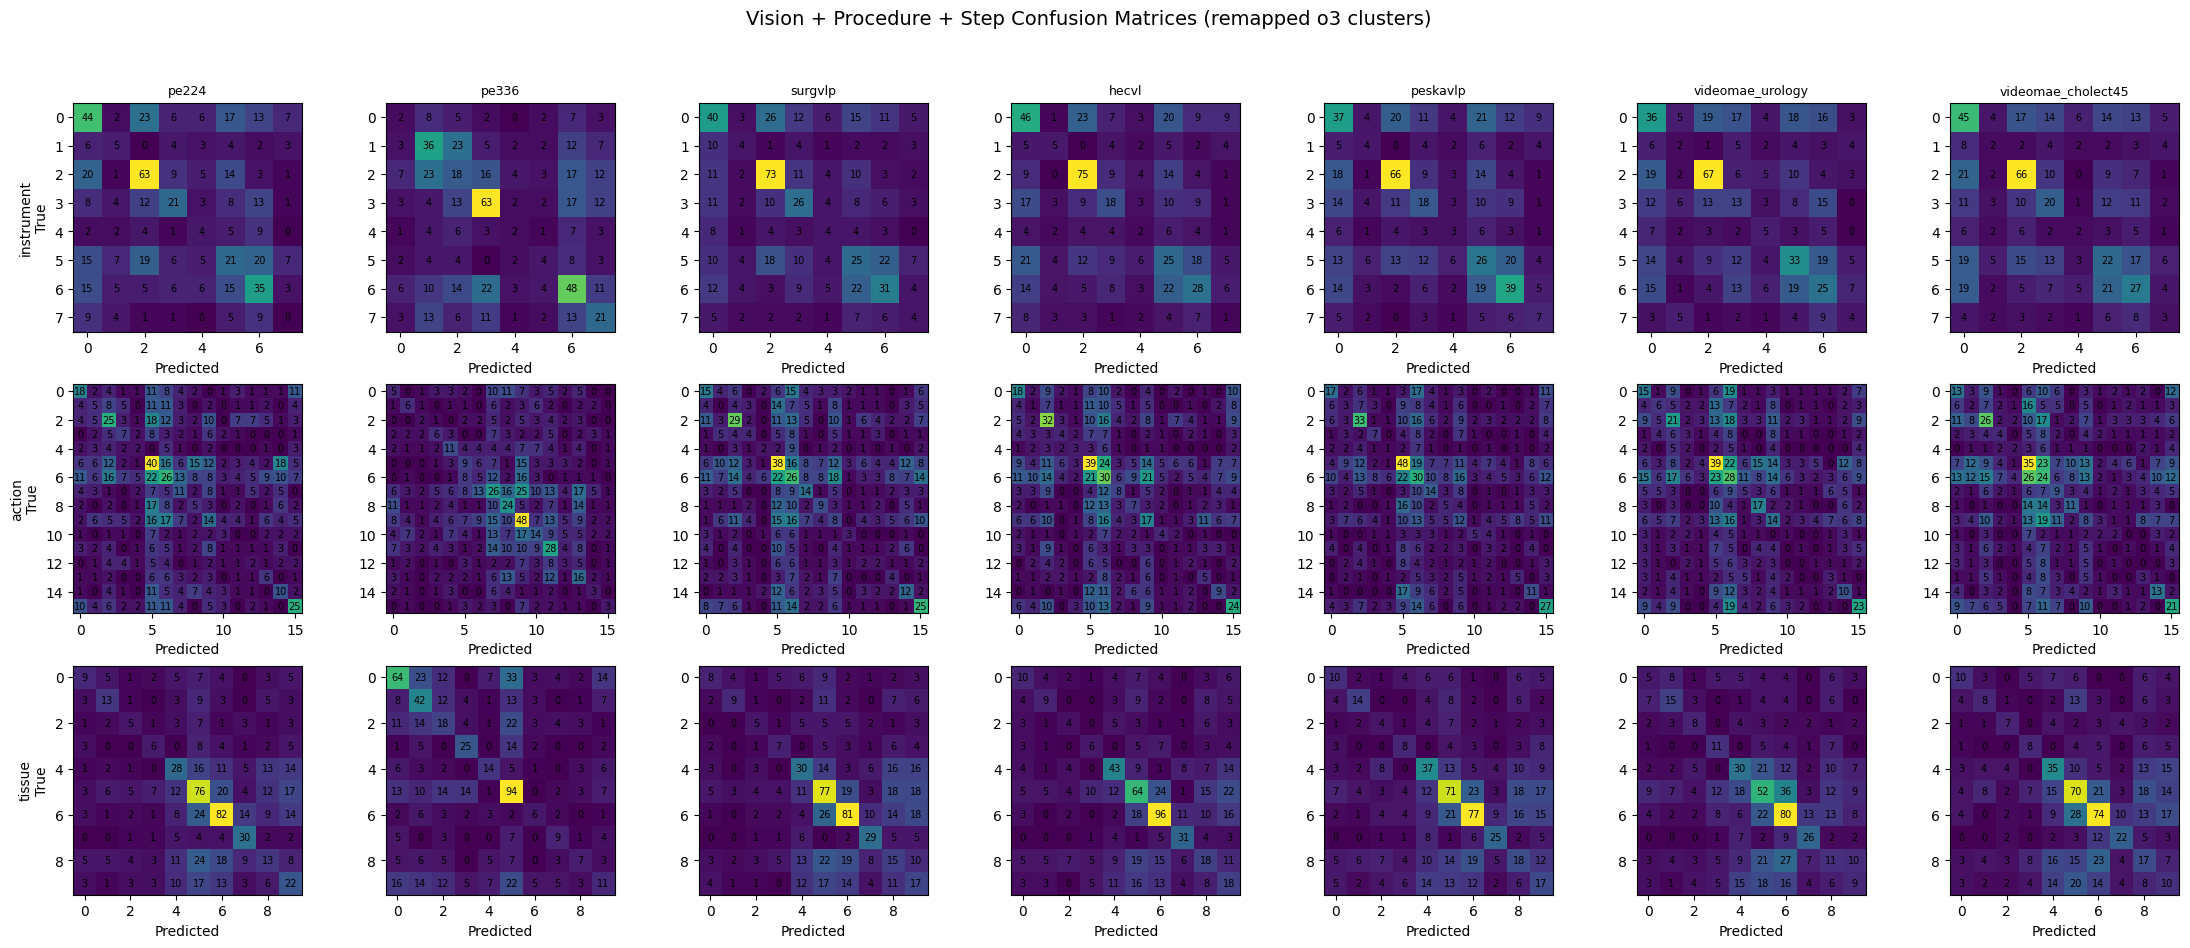

In [ ]:
vl_both_results_df = pd.read_csv(os.path.join(OUTPUT_DIR, f'vl_both_results-o3_clusters_remapped-include_none_label=100-label_count_filter=20.csv'))
# display(vl_both_results_df)
plot_confusion_matrices(
    vl_both_results_df, 
    'Vision + Procedure + Step Confusion Matrices (remapped o3 clusters)',
    models=['pe224', 'pe336', 'surgvlp', 'hecvl', 'peskavlp', 'videomae_urology', 'videomae_cholect45'],
)

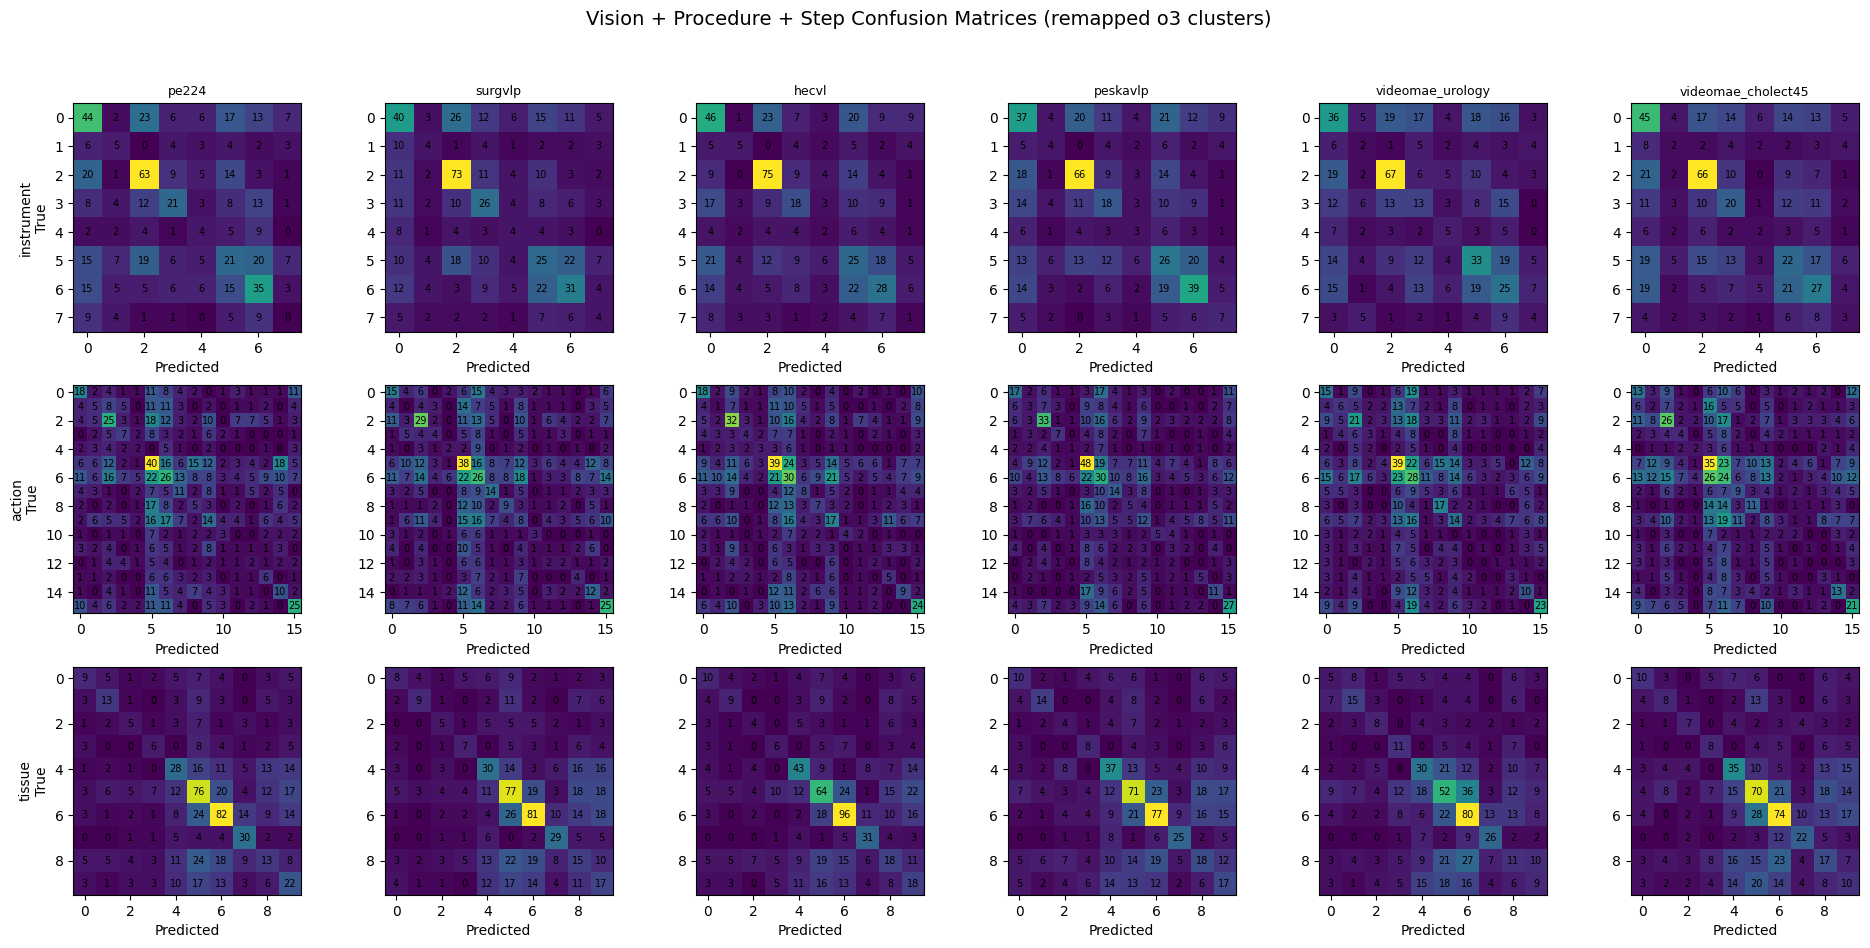

: 

In [ ]:
vl_both_results_df = pd.read_csv(os.path.join(OUTPUT_DIR, f'vl_both_results-o3_clusters_remapped-include_none_label=100-label_count_filter=20.csv'))
# display(vl_both_results_df)
plot_confusion_matrices(
    vl_both_results_df, 
    'Vision + Procedure + Step Confusion Matrices (remapped o3 clusters)',
    models=['pe224', 'surgvlp', 'hecvl', 'peskavlp', 'videomae_urology', 'videomae_cholect45'],
)

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,surgvlp,instrument,0.270365,0.675487,0.260784,0.225524,0.260784,0.233726,[[ 7 1 1 2 1 0 1 3 1 2 8 5]\n [ 1 ...,"[np.str_('7_fourth_arm_tenaculum_stitch'), np...."
1,surgvlp,action,0.082277,0.605750,0.082384,0.085874,0.082384,0.080855,[[5 2 0 ... 4 0 1]\n [1 4 0 ... 2 1 0]\n [0 3 ...,"[np.str_('24_lift_hold_advance_up'), np.str_('..."
2,surgvlp,tissue,0.300463,0.742294,0.282619,0.280510,0.282619,0.271768,[[27 1 2 5 1 0 2 1 9 2 13 1 0 1 9...,"[np.str_('0_vein_veins_complex_dorsal'), np.st..."
3,hecvl,instrument,0.245608,0.681825,0.241176,0.207897,0.241176,0.208029,[[ 2 0 0 0 1 1 0 5 4 4 7 8]\n [ 0 ...,"[np.str_('7_fourth_arm_tenaculum_stitch'), np...."
4,hecvl,action,0.078820,0.602633,0.086903,0.081568,0.086903,0.082326,[[0 2 5 ... 2 0 1]\n [1 5 1 ... 3 0 0]\n [0 2 ...,"[np.str_('24_lift_hold_advance_up'), np.str_('..."
5,hecvl,tissue,0.330131,0.761700,0.301199,0.296628,0.301199,0.289382,[[25 1 4 6 3 1 0 1 7 4 12 5 0 0 5...,"[np.str_('0_vein_veins_complex_dorsal'), np.st..."
6,peskavlp,instrument,0.280555,0.680654,0.241176,0.250711,0.241176,0.228408,[[ 4 1 1 1 0 2 6 1 3 4 5 4]\n [ 0 ...,"[np.str_('7_fourth_arm_tenaculum_stitch'), np...."
7,peskavlp,action,0.084317,0.602077,0.089914,0.089290,0.089914,0.086842,[[1 0 0 ... 2 0 1]\n [3 3 1 ... 0 4 0]\n [0 2 ...,"[np.str_('24_lift_hold_advance_up'), np.str_('..."
8,peskavlp,tissue,0.324900,0.751631,0.319767,0.324546,0.319767,0.312113,[[31 2 3 5 0 0 0 1 3 3 12 5 1 0 8...,"[np.str_('0_vein_veins_complex_dorsal'), np.st..."


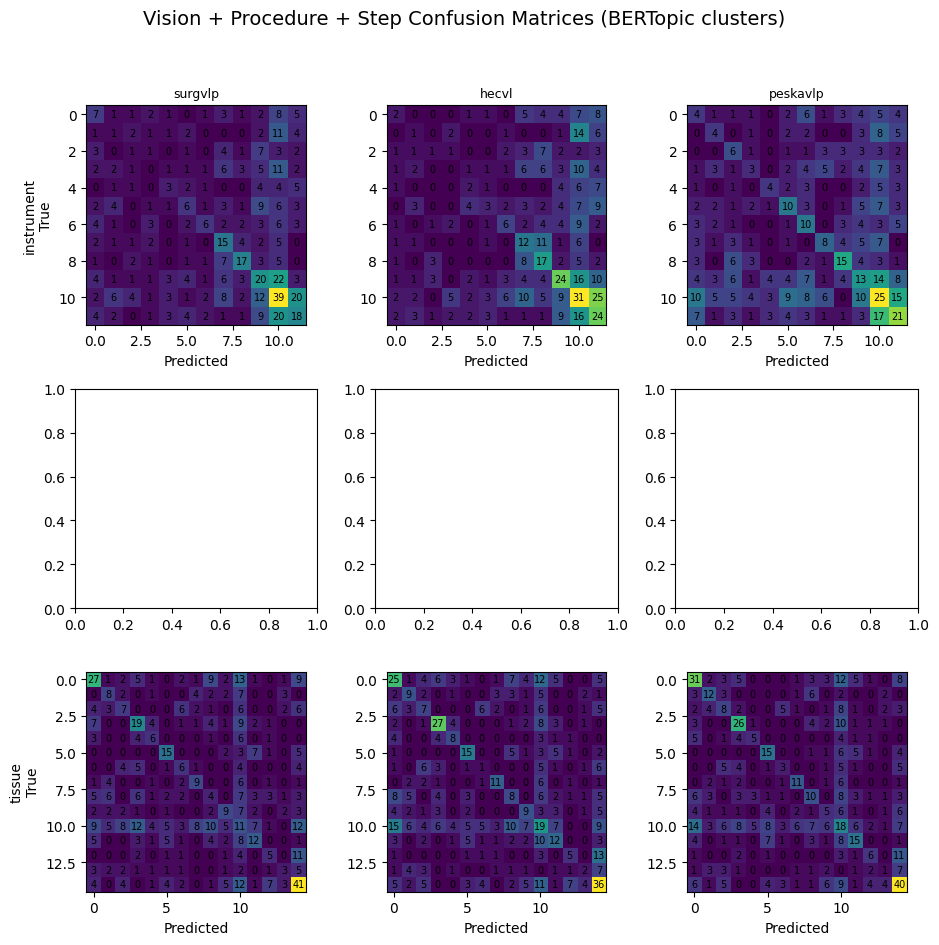

In [ ]:
vl_both_results_df = pd.read_csv(os.path.join(OUTPUT_DIR, f'vl_both_results-BERTopic_clusters-include_none_label=100-label_count_filter=20.csv'))
# display(vl_both_results_df)
plot_confusion_matrices(vl_both_results_df, 'Vision + Procedure + Step Confusion Matrices (BERTopic clusters)')

In [ ]:
vl_both_results_df

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,surgvlp,instrument,0.284394,0.687881,0.264451,0.268454,0.264451,0.259260,[[ 9 1 4 5 1 0 5 0 4 0]\n [ 0 5 5 ...,"[np.str_('suture_material'), np.str_('scissors..."
1,surgvlp,action,0.172917,0.624281,0.186999,0.174063,0.186999,0.175838,[[ 1 4 0 1 2 1 2 2 1 3 0 2 2 0 1...,"[np.str_('dissect'), np.str_('None'), np.str_(..."
2,surgvlp,tissue,0.343825,0.728577,0.339018,0.338560,0.339018,0.329639,[[ 3 3 7 0 5 6 4 0 0 0 1]\n [ 2 6 ...,"[np.str_('adrenal_kidney_region'), np.str_('pe..."
3,hecvl,instrument,0.303955,0.712397,0.264417,0.260748,0.264417,0.256630,[[ 9 1 5 3 2 0 6 0 3 0]\n [ 1 8 5 ...,"[np.str_('suture_material'), np.str_('scissors..."
4,hecvl,action,0.173200,0.617692,0.168863,0.168139,0.168863,0.161595,[[ 3 0 0 4 1 0 0 1 1 4 0 3 3 0 1...,"[np.str_('dissect'), np.str_('None'), np.str_(..."
5,hecvl,tissue,0.359333,0.735307,0.370597,0.360436,0.370597,0.351804,[[ 3 2 4 0 9 3 6 1 0 0 1]\n [ 1 4 ...,"[np.str_('adrenal_kidney_region'), np.str_('pe..."
6,peskavlp,instrument,0.314853,0.709074,0.305348,0.320505,0.305348,0.301221,[[11 0 3 2 3 0 0 0 9 1]\n [ 0 4 3 ...,"[np.str_('suture_material'), np.str_('scissors..."
7,peskavlp,action,0.165660,0.623117,0.181294,0.182614,0.181294,0.175002,[[ 3 2 1 1 1 0 1 2 2 5 0 3 1 0 1...,"[np.str_('dissect'), np.str_('None'), np.str_(..."
8,peskavlp,tissue,0.369163,0.736044,0.379704,0.381352,0.379704,0.374039,[[ 5 3 4 0 4 8 4 1 0 0 0]\n [ 2 5 ...,"[np.str_('adrenal_kidney_region'), np.str_('pe..."


In [ ]:
vl_proc_results_rows = []
models = ['surgvlp', 'hecvl', 'peskavlp'] # + ['videomae_urology', 'videomae_cholect45']
for model_name in models:
    for task in ['instrument', 'action', 'tissue']:
        col = f'{task}-cluster'
        print(f"Model: {model_name}, Task: {task}")
        vis_embs_avg, procedure_embs, teaching_step_embs, labels = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name)
        embeddings_comb = np.concatenate([vis_embs_avg, procedure_embs], axis=1)
        metrics, final_model = evaluate(embeddings_comb, labels, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))
        vl_proc_results_rows.append({
            'model': model_name,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
        })
vl_proc_results_df = pd.DataFrame(vl_proc_results_rows)

Model: surgvlp, Task: instrument
Embedding column: SurgVLP
No teaching step found for case 2 and timestamp 4543
No teaching step found for case 6 and timestamp 5621
No teaching step found for case 6 and timestamp 5630
No teaching step found for case 9 and timestamp 7397
No teaching step found for case 12 and timestamp 9342
No teaching step found for case 12 and timestamp 9353
No teaching step found for case 12 and timestamp 9367
No teaching step found for case 12 and timestamp 9382
No teaching step found for case 21 and timestamp 9549
No teaching step found for case 22 and timestamp 10675
Model: surgvlp, Task: action
Embedding column: SurgVLP
No teaching step found for case 2 and timestamp 4543
No teaching step found for case 6 and timestamp 5621
No teaching step found for case 6 and timestamp 5630
No teaching step found for case 9 and timestamp 7397
No teaching step found for case 12 and timestamp 9333
No teaching step found for case 12 and timestamp 9342
No teaching step found for ca

In [ ]:
vl_proc_results_path = os.path.join(OUTPUT_DIR, f'vl_proc_results-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)
vl_proc_results_df.to_csv(vl_proc_results_path, index=False)
vl_proc_results_df

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,surgvlp,instrument,0.831921,0.625159,0.847805,0.816203,0.847805,0.831106,"[[0, 0, 1, 0, 0, 0, 0, 30, 0, 0, 1, 0], [0, 2,...","[7_fourth_arm_tenaculum_stitch, 9_suture_sucti..."
1,surgvlp,action,0.328493,0.571731,0.369968,0.326174,0.369968,0.345319,"[[2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,...","[8_grab_swipe_scoop_lower, 32_sure_make_know_c..."
2,surgvlp,tissue,0.788580,0.649476,0.816504,0.771081,0.816504,0.789189,"[[7, 0, 1, 0, 0, 77, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[6_prostate_side_apex_apical, 5_bladder_cathet..."
3,hecvl,instrument,0.829688,0.627287,0.846564,0.815540,0.846564,0.829705,"[[0, 0, 0, 0, 0, 1, 0, 31, 0, 0, 0, 0], [0, 2,...","[7_fourth_arm_tenaculum_stitch, 9_suture_sucti..."
4,hecvl,action,0.330431,0.571354,0.369022,0.330831,0.369022,0.347398,"[[4, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,...","[8_grab_swipe_scoop_lower, 32_sure_make_know_c..."
5,hecvl,tissue,0.790002,0.666326,0.807108,0.765393,0.807108,0.784052,"[[7, 1, 0, 1, 0, 74, 1, 0, 0, 0, 1, 0, 0, 0, 0...","[6_prostate_side_apex_apical, 5_bladder_cathet..."
6,peskavlp,instrument,0.830152,0.613083,0.850513,0.816563,0.850513,0.832576,"[[0, 0, 0, 0, 0, 1, 0, 31, 0, 0, 0, 0], [0, 2,...","[7_fourth_arm_tenaculum_stitch, 9_suture_sucti..."
7,peskavlp,action,0.339853,0.575098,0.374497,0.333103,0.374497,0.349942,"[[2, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,...","[8_grab_swipe_scoop_lower, 32_sure_make_know_c..."
8,peskavlp,tissue,0.788121,0.661309,0.795262,0.768745,0.795262,0.780082,"[[9, 1, 0, 2, 0, 71, 1, 0, 0, 0, 0, 0, 0, 1, 0...","[6_prostate_side_apex_apical, 5_bladder_cathet..."


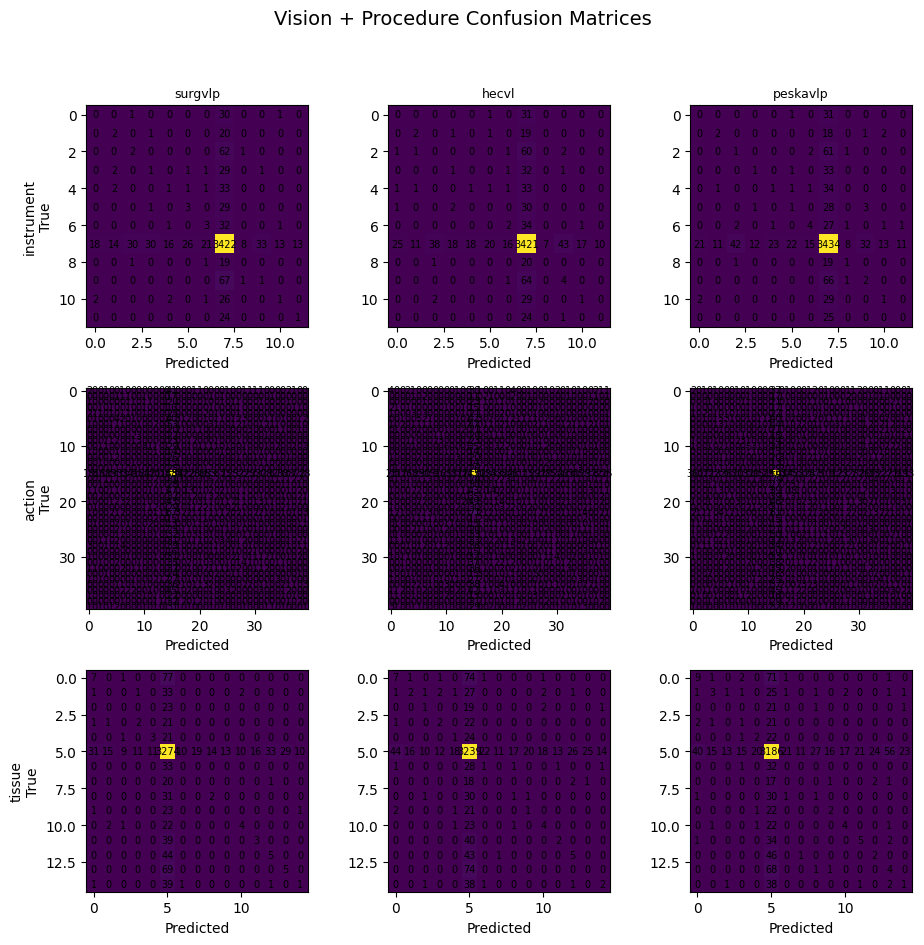

In [ ]:
plot_confusion_matrices(vl_proc_results_df, 'Vision + Procedure Confusion Matrices')

In [ ]:
vl_step_results_row = []
models = ['surgvlp', 'hecvl', 'peskavlp'] # + ['videomae_urology', 'videomae_cholect45']
for model_name in models:
    for task in ['instrument', 'action', 'tissue']:
        col = f'{task}-cluster'
        print(f"Model: {model_name}, Task: {task}")
        vis_embs_avg, procedure_embs, teaching_step_embs, labels = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, col, model_name)
        embeddings_comb = np.concatenate([vis_embs_avg, teaching_step_embs], axis=1)
        metrics, final_model = evaluate(embeddings_comb, labels, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))
        vl_step_results_row.append({
            'model': model_name,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
        })
vl_step_results_df = pd.DataFrame(vl_step_results_row)

Model: surgvlp, Task: instrument
Embedding column: SurgVLP
No teaching step found for case 2 and timestamp 4543
No teaching step found for case 6 and timestamp 5621
No teaching step found for case 6 and timestamp 5630
No teaching step found for case 9 and timestamp 7397
No teaching step found for case 12 and timestamp 9342
No teaching step found for case 12 and timestamp 9353
No teaching step found for case 12 and timestamp 9367
No teaching step found for case 12 and timestamp 9382
No teaching step found for case 21 and timestamp 9549
No teaching step found for case 22 and timestamp 10675
Model: surgvlp, Task: action
Embedding column: SurgVLP
No teaching step found for case 2 and timestamp 4543
No teaching step found for case 6 and timestamp 5621
No teaching step found for case 6 and timestamp 5630
No teaching step found for case 9 and timestamp 7397
No teaching step found for case 12 and timestamp 9333
No teaching step found for case 12 and timestamp 9342
No teaching step found for ca

In [ ]:
vl_step_results_path = os.path.join(OUTPUT_DIR, f'vl_step_results-include_none_label={INCLUDE_NONE_LABEL}-label_count_filter={LABEL_FILTER}.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)
vl_step_results_df.to_csv(vl_step_results_path, index=False)
vl_step_results_df

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,surgvlp,instrument,0.841266,0.652737,0.849773,0.818968,0.849773,0.833180,"[[0, 0, 0, 0, 0, 0, 0, 31, 0, 0, 1, 0], [0, 3,...","[7_fourth_arm_tenaculum_stitch, 9_suture_sucti..."
1,surgvlp,action,0.339450,0.586390,0.365928,0.331074,0.365928,0.346565,"[[2, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,...","[8_grab_swipe_scoop_lower, 32_sure_make_know_c..."
2,surgvlp,tissue,0.787666,0.664260,0.803164,0.767553,0.803164,0.783545,"[[9, 0, 0, 1, 0, 74, 0, 0, 0, 1, 0, 0, 0, 0, 0...","[6_prostate_side_apex_apical, 5_bladder_cathet..."
3,hecvl,instrument,0.834884,0.640791,0.843609,0.812799,0.843609,0.827685,"[[0, 0, 0, 0, 0, 0, 0, 32, 0, 0, 0, 0], [0, 1,...","[7_fourth_arm_tenaculum_stitch, 9_suture_sucti..."
4,hecvl,action,0.344512,0.581508,0.372835,0.332960,0.372835,0.349938,"[[1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[8_grab_swipe_scoop_lower, 32_sure_make_know_c..."
5,hecvl,tissue,0.798002,0.688357,0.816003,0.772380,0.816003,0.790929,"[[7, 0, 0, 1, 0, 75, 1, 0, 0, 0, 0, 0, 0, 1, 0...","[6_prostate_side_apex_apical, 5_bladder_cathet..."
6,peskavlp,instrument,0.832269,0.619078,0.841883,0.814006,0.841883,0.827112,"[[0, 0, 0, 0, 0, 1, 0, 31, 0, 0, 0, 0], [0, 1,...","[7_fourth_arm_tenaculum_stitch, 9_suture_sucti..."
7,peskavlp,action,0.342729,0.582466,0.377121,0.334584,0.377121,0.352581,"[[2, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[8_grab_swipe_scoop_lower, 32_sure_make_know_c..."
8,peskavlp,tissue,0.791563,0.678491,0.810575,0.766978,0.810575,0.787117,"[[9, 0, 0, 1, 0, 75, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[6_prostate_side_apex_apical, 5_bladder_cathet..."


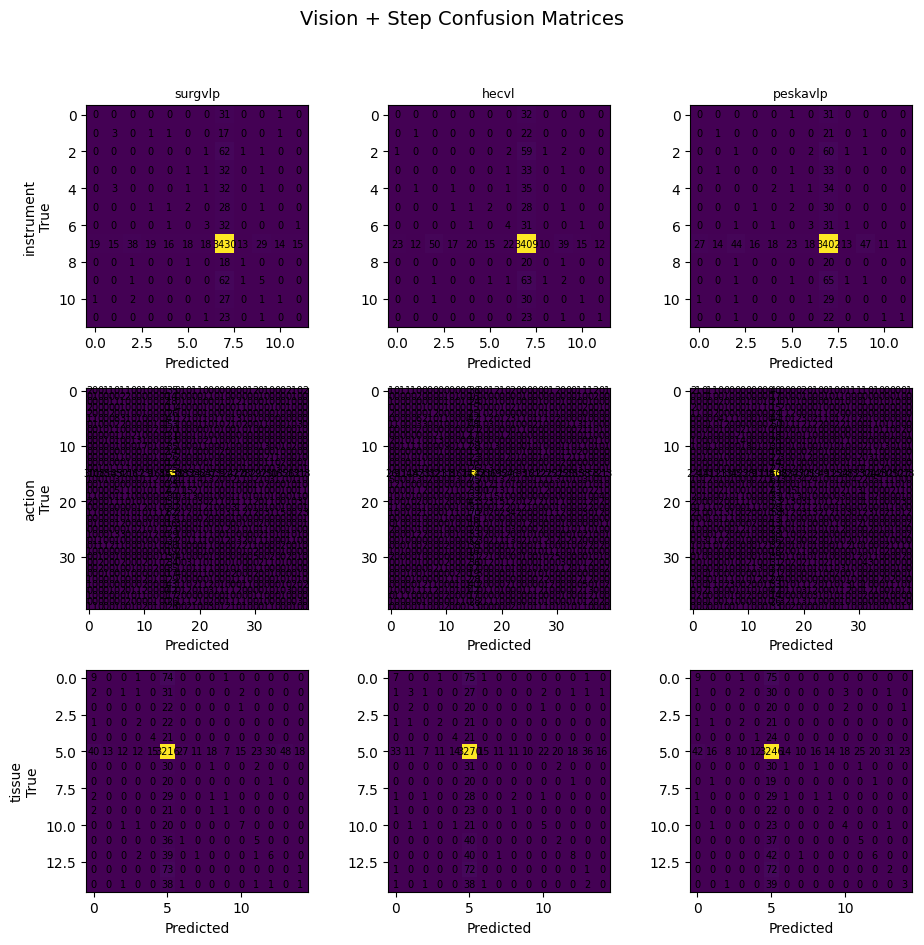

In [ ]:
plot_confusion_matrices(vl_step_results_df, 'Vision + Step Confusion Matrices')

In [ ]:
annotations_df.dropna(subset=['cholec-instrument', 'cholec-verb', 'cholec-target'])

,Dialogue,Timestamp,Case,cholec-instrument,cholec-verb,cholec-target,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid,surgvlp_vis_embs,hecvl_vis_embs,peskavlp_vis_embs,videomae_urology_vis_embs,videomae_cholect45_vis_embs
1305,"only one clip to artery, wanna be safe",15:07:52,10,clipper,clip,cystic_artery,0,0,1,1,1,1,0.0,c10_s0_0-57-14.avi,"[[-0.218241, 0.14799017, -0.15066056, -0.04007...","[[-0.051978618, 0.07885238, -0.10014723, -0.06...","[[0.2720564, -0.10362105, -0.8061497, -0.06026...","[[0.8023892, -0.33413947, 0.45415547, 0.882377...","[[0.08080265, -0.43143338, -0.1326618, -1.0527..."
2388,that's it you can grab that peritoneum and tha...,08:56:32,19,grasper,grasp,peritoneum,0,0,1,0,1,0,0.0,c19_s0_0-42-46.avi,"[[-0.07247958, -0.36457115, -0.22653162, -0.22...","[[-0.092505164, 0.042876754, 0.16805689, -2.49...","[[0.7040797, -0.4253269, -0.5862603, 0.5330626...","[[0.31401753, -0.30575362, 0.48872352, 0.66644...","[[-0.30642292, -0.53710645, -0.272817, 0.79999..."
2665,"you can do a few things here, you can either c...",14:47:35,22,clipper,clip,blood_vessel,0,0,1,1,1,0,0.0,c22_s0_0-41-27.avi,"[[-0.20784745, -0.011039101, -0.14139679, -0.2...","[[0.050256267, 0.23370668, 0.12443544, -0.2394...","[[-0.029525891, -0.104582384, -0.32320666, -0....","[[0.5601449, -0.30259085, 0.35234943, 0.855686...","[[-0.56726885, -0.39179355, -0.29148817, 0.237..."
2691,when you cut you have to have a little bit of...,14:50:50,22,clipper,cut,blood_vessel,0,0,1,0,1,0,0.0,c22_s0_0-44-42.avi,"[[0.013509471, 0.022852337, -0.20486107, -0.16...","[[0.03765872, 0.05131695, -0.07111819, -0.0237...","[[-0.29935688, -0.082929455, -0.41667575, 0.44...","[[-0.11704118, -0.45124024, 0.3219164, 0.88945...","[[-1.5093155, -0.20689838, -0.26261327, -0.157..."
2708,i would probably put another clip on the vein ...,14:53:36,22,clipper,clip,blood_vessel,0,0,1,0,1,0,0.0,c22_s0_0-47-28.avi,"[[-0.10460509, -0.113670796, -0.03884057, -0.1...","[[-0.07703532, 0.19327506, 0.054483257, -0.083...","[[0.2199919, -0.15217066, -0.31848693, -0.0081...","[[0.006109887, -0.4031441, 0.23085995, 0.69598...","[[-0.87298733, -0.5664707, -0.1386519, -1.0360..."


## Sample Predictions

In [ ]:
sample_df

,Dialogue,Timestamp,Case,cholec-instrument,cholec-verb,cholec-target,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid,surgvlp_vis_embs,hecvl_vis_embs,peskavlp_vis_embs,videomae_urology_vis_embs,videomae_cholect45_vis_embs
134,buzz that thing before it sinks away... the red,09:42:58,1,bipolar,NaN,NaN,0,0,0,0,1,0,0.0,c1_s0_1-5-33.avi,"[[-0.035562385, 0.06860658, -0.29392123, -0.38...","[[-0.018331263, 0.24699728, 0.11388082, 0.0645...","[[0.21770735, -1.0188081, -0.40162438, 0.12273...","[[0.02555764, 0.02005744, -0.28562903, 1.71609...","[[-0.4577906, -0.16275048, -0.08540602, -0.181..."
1263,coag that,14:42:50,10,bipolar,coagulate,NaN,0,0,0,0,1,0,0.0,c10_s0_0-32-12.avi,"[[0.011161208, -0.1677331, 0.23768932, -0.2935...","[[-0.0056118667, 0.08058088, 0.008873083, -0.0...","[[-0.3599007, -0.32758605, 0.3134495, 0.052875...","[[0.13171989, -0.29451677, 0.38280702, 0.30161...","[[-0.35208073, -0.5624867, 0.14015989, 0.11463..."
1273,see theres a vein there,14:45:17,10,NaN,NaN,blood_vessel,0,0,1,0,1,0,0.0,c10_s0_0-34-39.avi,"[[-0.11618999, 0.03901406, 0.23957314, -0.0295...","[[0.053698428, 0.044785447, 0.11267051, -0.071...","[[-0.24620855, -0.15478101, 0.35461366, 0.7465...","[[0.95825166, -0.4324911, 0.39184508, 0.383991...","[[0.89390206, -0.48457006, 0.013383354, -0.081..."
1305,"only one clip to artery, wanna be safe",15:07:52,10,clipper,clip,cystic_artery,0,0,1,1,1,1,0.0,c10_s0_0-57-14.avi,"[[-0.218241, 0.14799017, -0.15066056, -0.04007...","[[-0.051978618, 0.07885238, -0.10014723, -0.06...","[[0.2720564, -0.10362105, -0.8061497, -0.06026...","[[0.8023892, -0.33413947, 0.45415547, 0.882377...","[[0.08080265, -0.43143338, -0.1326618, -1.0527..."
2388,that's it you can grab that peritoneum and tha...,08:56:32,19,grasper,grasp,peritoneum,0,0,1,0,1,0,0.0,c19_s0_0-42-46.avi,"[[-0.07247958, -0.36457115, -0.22653162, -0.22...","[[-0.092505164, 0.042876754, 0.16805689, -2.49...","[[0.7040797, -0.4253269, -0.5862603, 0.5330626...","[[0.31401753, -0.30575362, 0.48872352, 0.66644...","[[-0.30642292, -0.53710645, -0.272817, 0.79999..."
2665,"you can do a few things here, you can either c...",14:47:35,22,clipper,clip,blood_vessel,0,0,1,1,1,0,0.0,c22_s0_0-41-27.avi,"[[-0.20784745, -0.011039101, -0.14139679, -0.2...","[[0.050256267, 0.23370668, 0.12443544, -0.2394...","[[-0.029525891, -0.104582384, -0.32320666, -0....","[[0.5601449, -0.30259085, 0.35234943, 0.855686...","[[-0.56726885, -0.39179355, -0.29148817, 0.237..."


In [ ]:
teaching_steps_df[teaching_steps_df['case_id'] == 10].iloc[6]['teaching_step_defn']

'Dissection involves carefully separating and isolating anatomical structures using surgical instruments, ensuring minimal trauma to surrounding tissues while providing clear visibility and access to the target area. This step is crucial for identifying critical structures and facilitating subsequent surgical maneuvers.'

In [ ]:
procedures_df.iloc[9]['procedure_defn']

"Nephrectomy is a surgical procedure that involves the removal of a kidney. It can be performed as a partial nephrectomy, where only a portion of the kidney is excised, or as a radical nephrectomy, which entails the complete removal of the kidney along with surrounding tissues, including the adrenal gland and nearby lymph nodes. This procedure is typically indicated for conditions such as kidney cancer, severe kidney damage, or donor kidney retrieval. Nephrectomy can be performed using open surgery or minimally invasive techniques, such as laparoscopic surgery, depending on the patient's condition and the surgeon's expertise."

In [ ]:
vision_results_df['pred-1'] = vision_results_df['sample_predictions'].apply(lambda x: x[1])
vision_results_df['pred-2'] = vision_results_df['sample_predictions'].apply(lambda x: x[3])
vision_results_df['pred-3'] = vision_results_df['sample_predictions'].apply(lambda x: x[4])
vision_results_df[['model', 'task', 'pred-1', 'pred-2', 'pred-3']]

,model,task,pred-1,pred-2,pred-3
0,surgvlp,instrument,scissors,bipolar,clipper
1,surgvlp,verb,grasp,cut,grasp
2,surgvlp,target,blood_vessel,blood_vessel,peritoneum
3,hecvl,instrument,scissors,scissors,scissors
4,hecvl,verb,grasp,grasp,grasp
5,hecvl,target,blood_vessel,blood_vessel,peritoneum
6,peskavlp,instrument,grasper,scissors,scissors
7,peskavlp,verb,grasp,retract,grasp
8,peskavlp,target,blood_vessel,blood_vessel,peritoneum
9,videomae_urology,instrument,bipolar,clipper,grasper


In [ ]:
vl_both_results_df['pred-1'] = vl_both_results_df['sample_predictions'].apply(lambda x: x[1])
vl_both_results_df['pred-2'] = vl_both_results_df['sample_predictions'].apply(lambda x: x[3])
vl_both_results_df['pred-3'] = vl_both_results_df['sample_predictions'].apply(lambda x: x[4])
vl_both_results_df[['model', 'task', 'pred-1', 'pred-2', 'pred-3']]

,model,task,pred-1,pred-2,pred-3
0,surgvlp,instrument,scissors,clipper,grasper
1,surgvlp,verb,cut,cut,grasp
2,surgvlp,target,blood_vessel,blood_vessel,peritoneum
3,hecvl,instrument,bipolar,clipper,grasper
4,hecvl,verb,coagulate,grasp,grasp
5,hecvl,target,blood_vessel,blood_vessel,peritoneum
6,peskavlp,instrument,bipolar,clipper,bipolar
7,peskavlp,verb,coagulate,grasp,grasp
8,peskavlp,target,blood_vessel,blood_vessel,peritoneum
9,videomae_urology,instrument,bipolar,clipper,grasper


In [ ]:
true_IVT_vision_rows = []
for i in range(len(sample_df)):
    row = sample_df.iloc[i]
    cvid = row['cvid']
    true_I = row['cholec-instrument']
    true_V = row['cholec-verb']
    true_T = row['cholec-target']
    
    # Vision
    tmp_df = vision_results_df.set_index(['model', 'task'])
    for model, task in tmp_df.index:
        true_IVT_vision_row = {
            'model': model,
            'task': task,
            
        }
        print(tmp_df.loc[(model, task)])
    
    # Vision + Procedure + Step

auprc_mean                                                          0.550646
auroc_mean                                                          0.609331
accuracy_mean                                                        0.45931
precision_mean                                                       0.45533
recall_mean                                                          0.45931
f1_mean                                                             0.445539
confusion_matrix           [[8, 5, 4, 3], [7, 49, 13, 9], [1, 15, 9, 4], ...
confusion_matrix_labels                [clipper, bipolar, scissors, grasper]
sample_predictions         [bipolar, scissors, bipolar, bipolar, clipper,...
Name: (surgvlp, instrument), dtype: object
auprc_mean                                                          0.523451
auroc_mean                                                          0.669195
accuracy_mean                                                       0.452218
precision_mean                   

In [ ]:
sample_df

,Dialogue,Timestamp,Case,cholec-instrument,cholec-verb,cholec-target,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid,surgvlp_vis_embs,hecvl_vis_embs,peskavlp_vis_embs,videomae_urology_vis_embs,videomae_cholect45_vis_embs
134,buzz that thing before it sinks away... the red,09:42:58,1,bipolar,NaN,NaN,0,0,0,0,1,0,0.0,c1_s0_1-5-33.avi,"[[-0.035562385, 0.06860658, -0.29392123, -0.38...","[[-0.018331263, 0.24699728, 0.11388082, 0.0645...","[[0.21770735, -1.0188081, -0.40162438, 0.12273...","[[0.02555764, 0.02005744, -0.28562903, 1.71609...","[[-0.4577906, -0.16275048, -0.08540602, -0.181..."
1263,coag that,14:42:50,10,bipolar,coagulate,NaN,0,0,0,0,1,0,0.0,c10_s0_0-32-12.avi,"[[0.011161208, -0.1677331, 0.23768932, -0.2935...","[[-0.0056118667, 0.08058088, 0.008873083, -0.0...","[[-0.3599007, -0.32758605, 0.3134495, 0.052875...","[[0.13171989, -0.29451677, 0.38280702, 0.30161...","[[-0.35208073, -0.5624867, 0.14015989, 0.11463..."
1273,see theres a vein there,14:45:17,10,NaN,NaN,blood_vessel,0,0,1,0,1,0,0.0,c10_s0_0-34-39.avi,"[[-0.11618999, 0.03901406, 0.23957314, -0.0295...","[[0.053698428, 0.044785447, 0.11267051, -0.071...","[[-0.24620855, -0.15478101, 0.35461366, 0.7465...","[[0.95825166, -0.4324911, 0.39184508, 0.383991...","[[0.89390206, -0.48457006, 0.013383354, -0.081..."
1305,"only one clip to artery, wanna be safe",15:07:52,10,clipper,clip,cystic_artery,0,0,1,1,1,1,0.0,c10_s0_0-57-14.avi,"[[-0.218241, 0.14799017, -0.15066056, -0.04007...","[[-0.051978618, 0.07885238, -0.10014723, -0.06...","[[0.2720564, -0.10362105, -0.8061497, -0.06026...","[[0.8023892, -0.33413947, 0.45415547, 0.882377...","[[0.08080265, -0.43143338, -0.1326618, -1.0527..."
2388,that's it you can grab that peritoneum and tha...,08:56:32,19,grasper,grasp,peritoneum,0,0,1,0,1,0,0.0,c19_s0_0-42-46.avi,"[[-0.07247958, -0.36457115, -0.22653162, -0.22...","[[-0.092505164, 0.042876754, 0.16805689, -2.49...","[[0.7040797, -0.4253269, -0.5862603, 0.5330626...","[[0.31401753, -0.30575362, 0.48872352, 0.66644...","[[-0.30642292, -0.53710645, -0.272817, 0.79999..."
2665,"you can do a few things here, you can either c...",14:47:35,22,clipper,clip,blood_vessel,0,0,1,1,1,0,0.0,c22_s0_0-41-27.avi,"[[-0.20784745, -0.011039101, -0.14139679, -0.2...","[[0.050256267, 0.23370668, 0.12443544, -0.2394...","[[-0.029525891, -0.104582384, -0.32320666, -0....","[[0.5601449, -0.30259085, 0.35234943, 0.855686...","[[-0.56726885, -0.39179355, -0.29148817, 0.237..."


In [ ]:
for model, task in tmp_df.index:
    print(model, task)

surgvlp instrument
surgvlp verb
surgvlp target
hecvl instrument
hecvl verb
hecvl target
peskavlp instrument
peskavlp verb
peskavlp target
videomae_urology instrument
videomae_urology verb
videomae_urology target
videomae_cholect45 instrument
videomae_cholect45 verb
videomae_cholect45 target


In [ ]:
annotations_df

NameError: name 'annotations_df' is not defined